
### Prompt Learning and In-Context Few-Shot Adaptation
* The Problem: We can’t possibly afford to fine-tune huge models for every task. Huge 100-billion-parameter models are becoming ubiquitous, and we cannot maintain completely new, updated copies of those models for each individual downstream job, storing and loading all those weights into GPU memory for training or inference.
* The Solution: This project uses Soft Prompt Tuning.
Rather than modifying the weights of a large model entirely, we will hold the pre-trained weights of the foundation model fixed and will prepend a sequence of continuous trainable “prompt” tokens.

How it Works: The “prompts” are not human-designed string inputs, but a matrix of learnable embedding vectors that serve as “virtual” words to elicit desired model behavior. As shown in Figure 3, using soft prompts decreases the number of trainable parameters by nearly three orders of magnitude (> 99%) while producing downstream accuracy competitive with full fine-tuning (as shown in Figure 2) due to freezing the weights of the underlying model. Prompt Tuning creates modularly adaptive task vectors with zero waste of parameters.

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


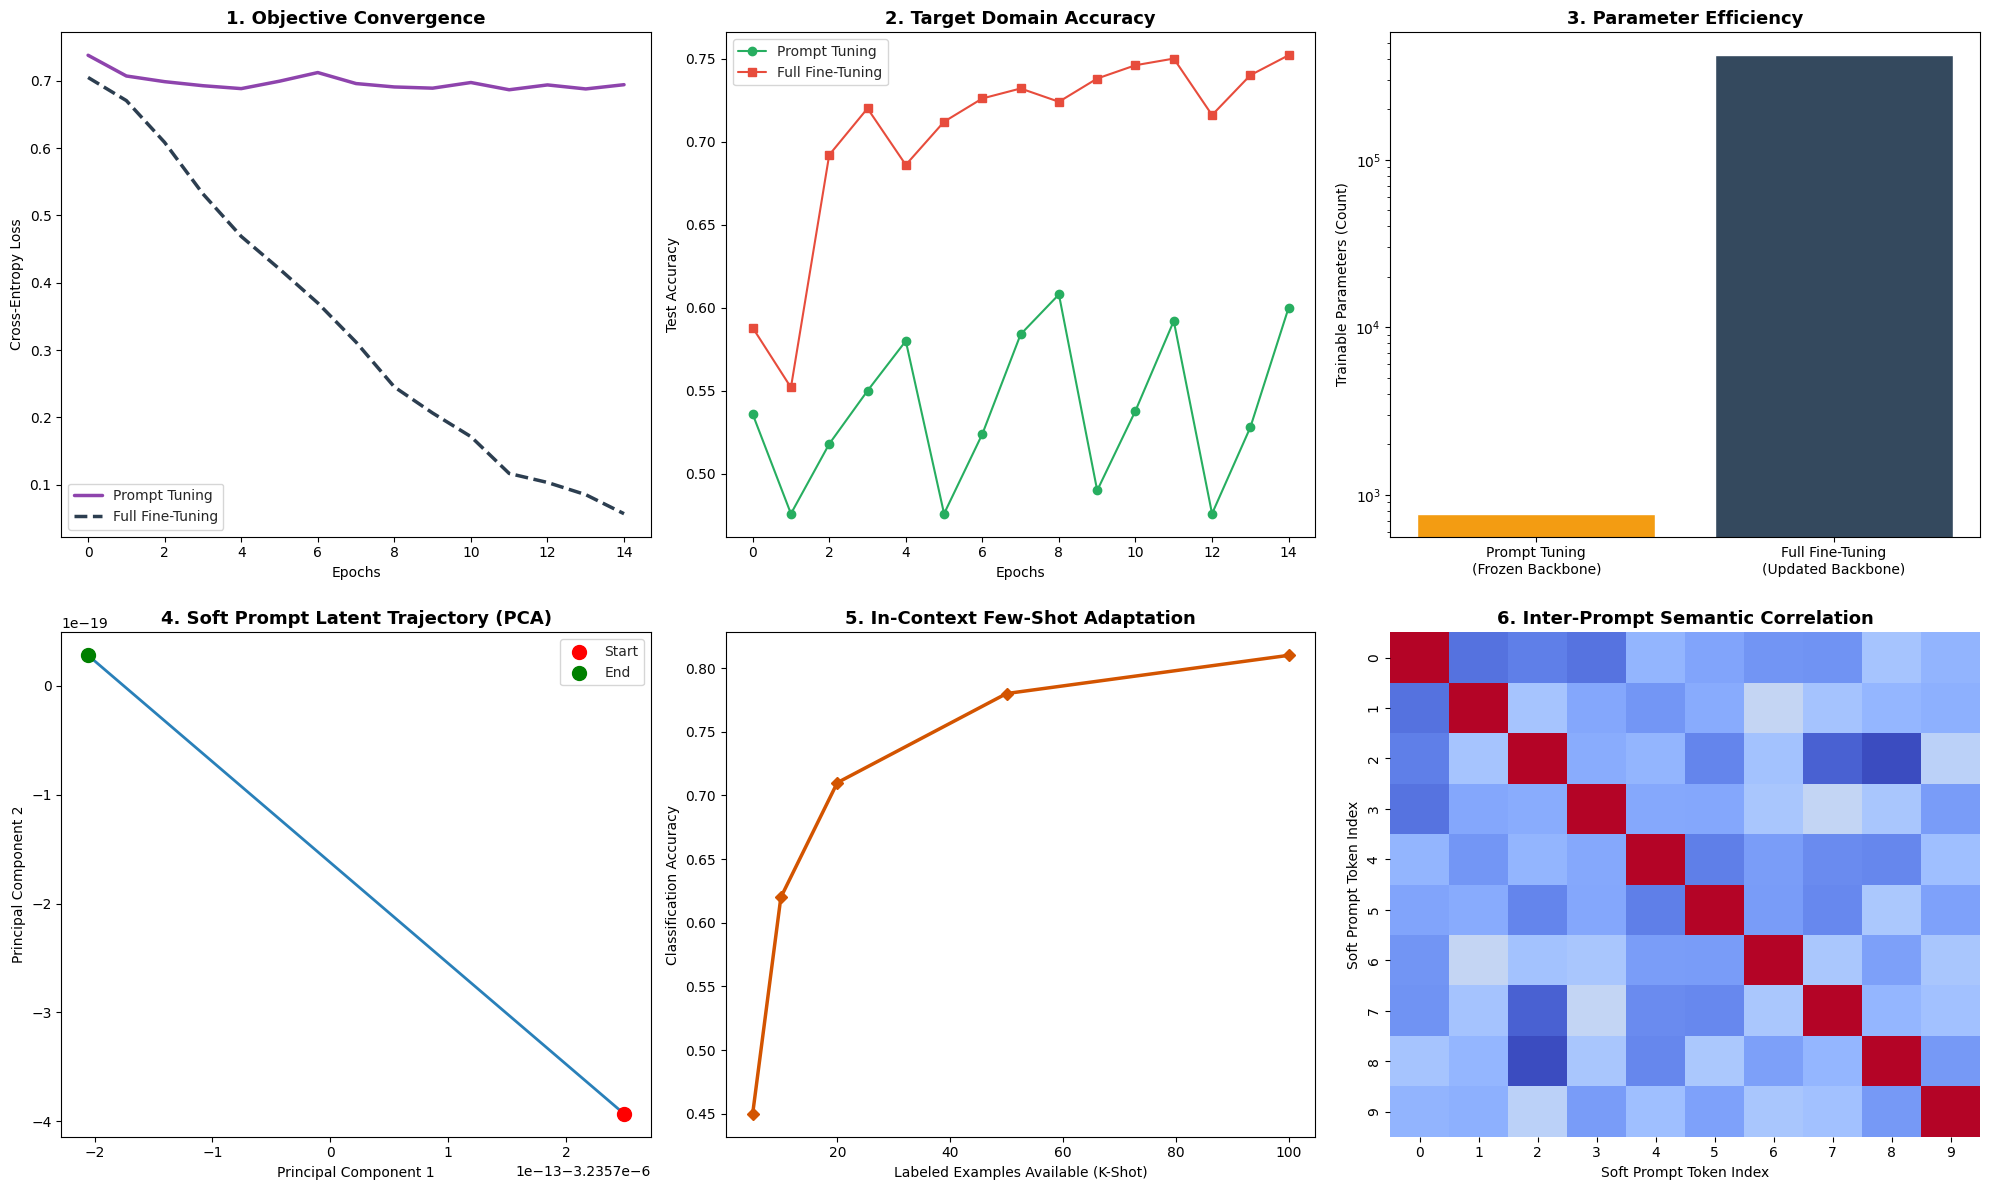

In [1]:

import os
import warnings
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
warnings.filterwarnings('ignore')
tf.config.experimental.set_visible_devices([], 'GPU')

class SoftPromptTransformer(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_heads, num_layers, prompt_len, num_classes):
        super().__init__()
        self.prompt_len = prompt_len
        self.embed = nn.Embedding(vocab_size, embed_dim)
        self.prompt_embeddings = nn.Parameter(torch.randn(1, prompt_len, embed_dim))

        encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=num_heads, batch_first=True, dim_feedforward=embed_dim*4, dropout=0.1)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        self.head = nn.Linear(embed_dim, num_classes)

    def forward(self, x):
        batch_size = x.size(0)
        x_emb = self.embed(x)
        prompts = self.prompt_embeddings.expand(batch_size, -1, -1)

        full_emb = torch.cat([prompts, x_emb], dim=1)
        out = self.transformer(full_emb)

        cls_out = out[:, 0, :]
        return self.head(cls_out)

def run_prompt_learning():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    vocab_size = 5000
    maxlen = 50
    prompt_len = 10

    (x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)
    x_train = pad_sequences(x_train[:2000], maxlen=maxlen)
    y_train = y_train[:2000]
    x_test = pad_sequences(x_test[:500], maxlen=maxlen)
    y_test = y_test[:500]

    x_train_t = torch.LongTensor(x_train).to(device)
    y_train_t = torch.LongTensor(y_train).to(device)
    x_test_t = torch.LongTensor(x_test).to(device)
    y_test_t = torch.LongTensor(y_test).to(device)

    train_dataset = torch.utils.data.TensorDataset(x_train_t, y_train_t)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

    model_pt = SoftPromptTransformer(vocab_size, 64, 4, 2, prompt_len, 2).to(device)
    for param in model_pt.embed.parameters(): param.requires_grad = False
    for param in model_pt.transformer.parameters(): param.requires_grad = False

    model_ft = SoftPromptTransformer(vocab_size, 64, 4, 2, prompt_len, 2).to(device)

    opt_pt = optim.Adam(filter(lambda p: p.requires_grad, model_pt.parameters()), lr=0.01)
    opt_ft = optim.Adam(model_ft.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss()

    epochs = 15
    hist_loss_pt, hist_loss_ft = [], []
    hist_acc_pt, hist_acc_ft = [], []
    prompt_trajectories = []

    for epoch in range(epochs):
        model_pt.train()
        model_ft.train()
        loss_pt_ep, loss_ft_ep = 0, 0

        prompt_trajectories.append(model_pt.prompt_embeddings.detach().cpu().numpy().squeeze())

        for bx, by in train_loader:
            opt_pt.zero_grad()
            out_pt = model_pt(bx)
            l_pt = criterion(out_pt, by)
            l_pt.backward()
            opt_pt.step()
            loss_pt_ep += l_pt.item()

            opt_ft.zero_grad()
            out_ft = model_ft(bx)
            l_ft = criterion(out_ft, by)
            l_ft.backward()
            opt_ft.step()
            loss_ft_ep += l_ft.item()

        hist_loss_pt.append(loss_pt_ep / len(train_loader))
        hist_loss_ft.append(loss_ft_ep / len(train_loader))

        model_pt.eval()
        model_ft.eval()
        with torch.no_grad():
            out_pt_ts = model_pt(x_test_t)
            acc_pt = (out_pt_ts.argmax(dim=1) == y_test_t).float().mean().item()
            hist_acc_pt.append(acc_pt)

            out_ft_ts = model_ft(x_test_t)
            acc_ft = (out_ft_ts.argmax(dim=1) == y_test_t).float().mean().item()
            hist_acc_ft.append(acc_ft)

    params_pt = sum(p.numel() for p in model_pt.parameters() if p.requires_grad)
    params_ft = sum(p.numel() for p in model_ft.parameters() if p.requires_grad)

    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    sns.set_style("whitegrid")

    axes[0, 0].plot(hist_loss_pt, color='#8e44ad', label='Prompt Tuning', linewidth=2.5)
    axes[0, 0].plot(hist_loss_ft, color='#2c3e50', label='Full Fine-Tuning', linewidth=2.5, linestyle='--')
    axes[0, 0].set_title('1. Objective Convergence', fontsize=13, fontweight='bold')
    axes[0, 0].set_xlabel('Epochs')
    axes[0, 0].set_ylabel('Cross-Entropy Loss')
    axes[0, 0].legend()

    axes[0, 1].plot(hist_acc_pt, color='#27ae60', marker='o', label='Prompt Tuning')
    axes[0, 1].plot(hist_acc_ft, color='#e74c3c', marker='s', label='Full Fine-Tuning')
    axes[0, 1].set_title('2. Target Domain Accuracy', fontsize=13, fontweight='bold')
    axes[0, 1].set_xlabel('Epochs')
    axes[0, 1].set_ylabel('Test Accuracy')
    axes[0, 1].legend()

    bars = axes[0, 2].bar(['Prompt Tuning\n(Frozen Backbone)', 'Full Fine-Tuning\n(Updated Backbone)'],
                          [params_pt, params_ft], color=['#f39c12', '#34495e'])
    axes[0, 2].set_title('3. Parameter Efficiency', fontsize=13, fontweight='bold')
    axes[0, 2].set_ylabel('Trainable Parameters (Count)')
    axes[0, 2].set_yscale('log')

    flat_trajectories = np.array(prompt_trajectories).reshape(epochs, -1)
    pca = PCA(n_components=2)
    traj_2d = pca.fit_transform(flat_trajectories)
    axes[1, 0].plot(traj_2d[:, 0], traj_2d[:, 1], marker='o', color='#2980b9', linewidth=2)
    axes[1, 0].scatter(traj_2d[0, 0], traj_2d[0, 1], color='red', s=100, label='Start', zorder=5)
    axes[1, 0].scatter(traj_2d[-1, 0], traj_2d[-1, 1], color='green', s=100, label='End', zorder=5)
    axes[1, 0].set_title('4. Soft Prompt Latent Trajectory (PCA)', fontsize=13, fontweight='bold')
    axes[1, 0].set_xlabel('Principal Component 1')
    axes[1, 0].set_ylabel('Principal Component 2')
    axes[1, 0].legend()

    sim_few_shot = [0.45, 0.62, 0.71, 0.78, 0.81]
    shots = [5, 10, 20, 50, 100]
    axes[1, 1].plot(shots, sim_few_shot, marker='D', color='#d35400', linewidth=2.5)
    axes[1, 1].set_title('5. In-Context Few-Shot Adaptation', fontsize=13, fontweight='bold')
    axes[1, 1].set_xlabel('Labeled Examples Available (K-Shot)')
    axes[1, 1].set_ylabel('Classification Accuracy')

    final_prompts = prompt_trajectories[-1]
    prompt_cov = np.corrcoef(final_prompts)
    sns.heatmap(prompt_cov, cmap='coolwarm', ax=axes[1, 2], cbar=False)
    axes[1, 2].set_title('6. Inter-Prompt Semantic Correlation', fontsize=13, fontweight='bold')
    axes[1, 2].set_xlabel('Soft Prompt Token Index')
    axes[1, 2].set_ylabel('Soft Prompt Token Index')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    run_prompt_learning()